In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ashery/chexpert/train.csv")
df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [2]:
df = df[df['Frontal/Lateral'] == 'Frontal']

In [3]:
df = df[['Path','Pneumonia','Pleural Effusion']]

df.head()

,Path,Pneumonia,Pleural Effusion
0,CheXpert-v1.0-small/train/patient00001/study1/...,NaN,NaN
1,CheXpert-v1.0-small/train/patient00002/study2/...,NaN,-1.0
2,CheXpert-v1.0-small/train/patient00002/study1/...,NaN,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,NaN,NaN
5,CheXpert-v1.0-small/train/patient00004/study1/...,NaN,0.0


In [4]:
combo_counts = df.groupby(['Pneumonia','Pleural Effusion']).size()

print("\nLABEL COMBINATIONS\n")
print(combo_counts)


LABEL COMBINATIONS

Pneumonia  Pleural Effusion
-1.0       -1.0                 766
            0.0                1127
            1.0                6099
 0.0       -1.0                  43
            0.0                 226
            1.0                 184
 1.0       -1.0                 213
            0.0                 348
            1.0                1396
dtype: int64


In [5]:
print("\nMISSING VALUES\n")
print(df[['Pneumonia','Pleural Effusion']].isna().sum())


MISSING VALUES

Pneumonia           168496
Pleural Effusion     79251
dtype: int64


In [6]:
summary = pd.DataFrame({
    "Pneumonia": df['Pneumonia'].value_counts(dropna=False),
    "Pleural Effusion": df['Pleural Effusion'].value_counts(dropna=False)
})

print(summary)

      Pneumonia  Pleural Effusion
-1.0      15981              9578
 0.0       1875             25299
 1.0       4675             76899
 NaN     168496             79251


In [7]:
clean_df = df.copy()

clean_df = clean_df.fillna(0)
clean_df = clean_df.replace(-1,0)

clean_df[['Pneumonia','Pleural Effusion']].value_counts()

Pneumonia  Pleural Effusion
0.0        0.0                 110849
           1.0                  75503
1.0        0.0                   3279
           1.0                   1396
Name: count, dtype: int64

In [8]:
clean_df['Pneumonia'] = clean_df['Pneumonia'].replace(-1, 1)
clean_df['Pleural Effusion'] = clean_df['Pleural Effusion'].replace(-1, 0)

# Check new combinations
combo_counts = clean_df.groupby(['Pneumonia','Pleural Effusion']).size()
print(combo_counts)

Pneumonia  Pleural Effusion
0.0        0.0                 110849
           1.0                  75503
1.0        0.0                   3279
           1.0                   1396
dtype: int64


In [9]:
import pandas as pd

# reload raw CSV
df = pd.read_csv("/kaggle/input/datasets/ashery/chexpert/train.csv")

# keep only relevant columns
df = df[['Path','Pneumonia','Pleural Effusion']]

In [10]:
df = df.fillna(0)  # NaN → 0

In [11]:
df['Pneumonia'] = df['Pneumonia'].replace(-1, 1)          # make uncertain Pneumonia positive
df['Pleural Effusion'] = df['Pleural Effusion'].replace(-1, 0)  # keep Effusion uncertain as negative

In [12]:
combo_counts = df.groupby(['Pneumonia','Pleural Effusion']).size()
print(combo_counts)

Pneumonia  Pleural Effusion
0.0        0.0                 121214
           1.0                  77391
1.0        0.0                  16013
           1.0                   8796
dtype: int64


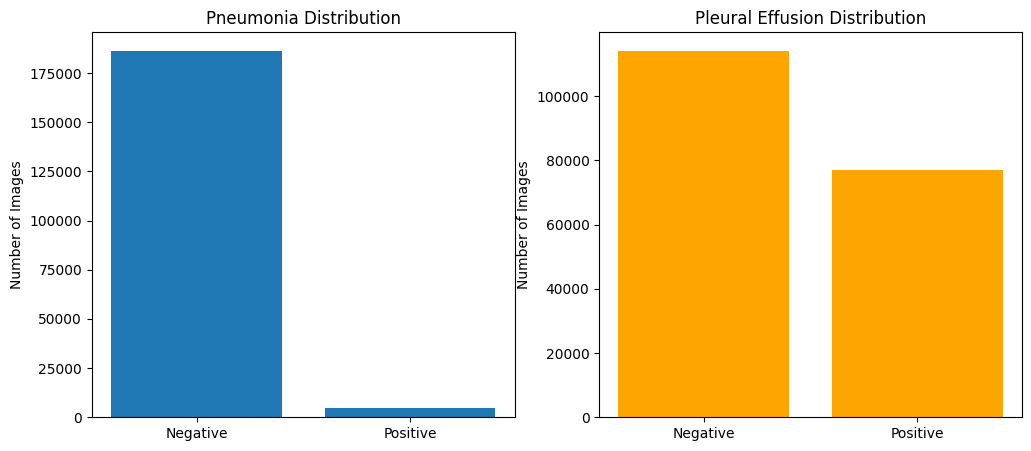

In [13]:
import matplotlib.pyplot as plt

# count positives and negatives
pneumonia_counts = clean_df['Pneumonia'].value_counts()
effusion_counts = clean_df['Pleural Effusion'].value_counts()

# plot
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].bar(['Negative','Positive'], pneumonia_counts)
axes[0].set_title('Pneumonia Distribution')
axes[0].set_ylabel('Number of Images')

axes[1].bar(['Negative','Positive'], effusion_counts, color='orange')
axes[1].set_title('Pleural Effusion Distribution')
axes[1].set_ylabel('Number of Images')

plt.show()

/tmp/ipykernel_55/1357310822.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['0,0','0,1','1,0','1,1'], y=combo_counts['count'], palette='viridis')


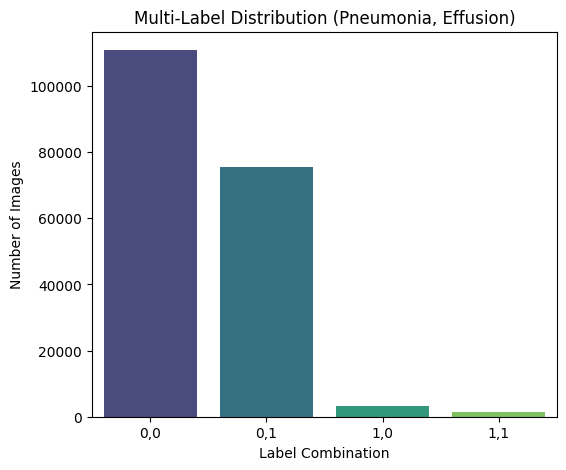

In [14]:
import seaborn as sns

# get combinations
combo_counts = clean_df.groupby(['Pneumonia','Pleural Effusion']).size().reset_index(name='count')

# plot
plt.figure(figsize=(6,5))
sns.barplot(x=['0,0','0,1','1,0','1,1'], y=combo_counts['count'], palette='viridis')
plt.title('Multi-Label Distribution (Pneumonia, Effusion)')
plt.ylabel('Number of Images')
plt.xlabel('Label Combination')
plt.show()

In [15]:
import pandas as pd

# load validation CSV
val_df = pd.read_csv("/kaggle/input/datasets/ashery/chexpert/valid.csv")

# keep only relevant columns
val_df = val_df[['Path','Pneumonia','Pleural Effusion']]

# check first few rows
val_df.head()

,Path,Pneumonia,Pleural Effusion
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0.0,0.0
2,CheXpert-v1.0-small/valid/patient64542/study1/...,0.0,0.0
3,CheXpert-v1.0-small/valid/patient64543/study1/...,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64544/study1/...,0.0,0.0


In [16]:
# count values for each disease
print("PNEUMONIA VALUE COUNTS (Validation):")
print(val_df['Pneumonia'].value_counts(dropna=False))

print("\nPLEURAL EFFUSION VALUE COUNTS (Validation):")
print(val_df['Pleural Effusion'].value_counts(dropna=False))

# combinations
combo_counts_val = val_df.groupby(['Pneumonia','Pleural Effusion']).size()
print("\nLABEL COMBINATIONS (Validation):")
print(combo_counts_val)

PNEUMONIA VALUE COUNTS (Validation):
Pneumonia
0.0    226
1.0      8
Name: count, dtype: int64

PLEURAL EFFUSION VALUE COUNTS (Validation):
Pleural Effusion
0.0    167
1.0     67
Name: count, dtype: int64

LABEL COMBINATIONS (Validation):
Pneumonia  Pleural Effusion
0.0        0.0                 166
           1.0                  60
1.0        0.0                   1
           1.0                   7
dtype: int64


In [17]:
# NaN → 0
val_df = val_df.fillna(0)

# Pneumonia -1 → 1, Effusion -1 → 0
val_df['Pneumonia'] = val_df['Pneumonia'].replace(-1,1)
val_df['Pleural Effusion'] = val_df['Pleural Effusion'].replace(-1,0)

# check updated combinations
combo_counts_val = val_df.groupby(['Pneumonia','Pleural Effusion']).size()
print("\nUPDATED LABEL COMBINATIONS (Validation):")
print(combo_counts_val)


UPDATED LABEL COMBINATIONS (Validation):
Pneumonia  Pleural Effusion
0.0        0.0                 166
           1.0                  60
1.0        0.0                   1
           1.0                   7
dtype: int64


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
# 1️⃣ Start fresh from the original cleaned df
clean_df_final = df.copy()  # df = raw CSV with NaN handled

# NaN → 0
clean_df_final = clean_df_final.fillna(0)

# Pneumonia -1 → 1, Effusion -1 → 0
clean_df_final['Pneumonia'] = clean_df_final['Pneumonia'].replace(-1,1)
clean_df_final['Pleural Effusion'] = clean_df_final['Pleural Effusion'].replace(-1,0)

# 2️⃣ Create stratified split
clean_df_final['combo_label'] = clean_df_final['Pneumonia'].astype(str) + '_' + clean_df_final['Pleural Effusion'].astype(str)

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    clean_df_final,
    test_size=0.05,
    random_state=42,
    stratify=clean_df_final['combo_label']
)

# Drop helper
train_df = train_df.drop(columns=['combo_label'])
val_df = val_df.drop(columns=['combo_label'])

# 3️⃣ Check training distribution
train_df.groupby(['Pneumonia','Pleural Effusion']).size()

Pneumonia  Pleural Effusion
0.0        0.0                 115153
           1.0                  73522
1.0        0.0                  15212
           1.0                   8356
dtype: int64

In [20]:
# display first 5 rows
val_df.head()

,Path,Pneumonia,Pleural Effusion
83582,CheXpert-v1.0-small/train/patient20132/study3/...,0.0,0.0
7939,CheXpert-v1.0-small/train/patient01955/study7/...,0.0,1.0
129950,CheXpert-v1.0-small/train/patient31120/study5/...,0.0,0.0
95530,CheXpert-v1.0-small/train/patient22972/study8/...,0.0,1.0
185248,CheXpert-v1.0-small/train/patient43906/study2/...,0.0,1.0


In [21]:
# Pneumonia
print("Pneumonia value counts (Validation):")
print(val_df['Pneumonia'].value_counts())

# Effusion
print("\nPleural Effusion value counts (Validation):")
print(val_df['Pleural Effusion'].value_counts())

Pneumonia value counts (Validation):
Pneumonia
0.0    9930
1.0    1241
Name: count, dtype: int64

Pleural Effusion value counts (Validation):
Pleural Effusion
0.0    6862
1.0    4309
Name: count, dtype: int64


In [22]:
combo_counts_val = val_df.groupby(['Pneumonia','Pleural Effusion']).size()
print("\nLabel combinations (Validation):")
print(combo_counts_val)


Label combinations (Validation):
Pneumonia  Pleural Effusion
0.0        0.0                 6061
           1.0                 3869
1.0        0.0                  801
           1.0                  440
dtype: int64


/tmp/ipykernel_55/2832193646.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['0,0','0,1','1,0','1,1'], y=combo_counts_val_df['count'], palette='viridis')


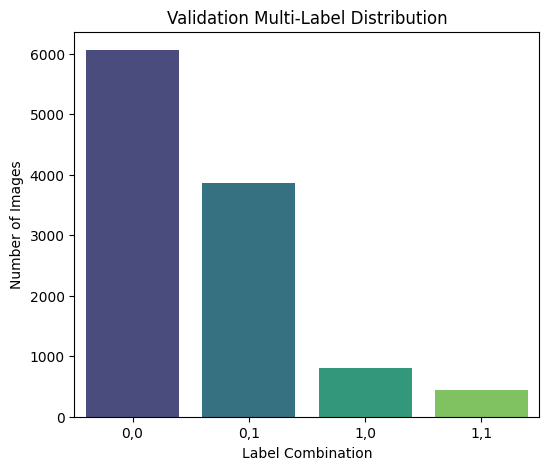

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# multi-label distribution
combo_counts_val_df = combo_counts_val.reset_index(name='count')
plt.figure(figsize=(6,5))
sns.barplot(x=['0,0','0,1','1,0','1,1'], y=combo_counts_val_df['count'], palette='viridis')
plt.title('Validation Multi-Label Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Label Combination')
plt.show()

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

In [25]:
csv_path = "/kaggle/input/datasets/ashery/chexpert/train.csv"
root_dir = "/kaggle/input/datasets/ashery/chexpert"  # folder containing train/valid subfolders

# Load CSV
df = pd.read_csv(csv_path)
# Add this right after reading the CSV
df = df[df['Frontal/Lateral'] == 'Frontal']

# Fill missing values and handle uncertain labels
df = df.fillna(0)
df['Pneumonia'] = df['Pneumonia'].replace(-1, 1)
df['Pleural Effusion'] = df['Pleural Effusion'].replace(-1, 0)

# Optional: split into train/validation (5% val)
from sklearn.model_selection import train_test_split

df['combo_label'] = df['Pneumonia'].astype(str) + '_' + df['Pleural Effusion'].astype(str)

train_df, val_df = train_test_split(
    df,
    test_size=0.05,
    random_state=42,
    stratify=df['combo_label']
)

# Drop helper column
train_df = train_df.drop(columns=['combo_label'])
val_df = val_df.drop(columns=['combo_label'])

# Check distribution
print("Train label combos:\n", train_df.groupby(['Pneumonia','Pleural Effusion']).size())
print("\nValidation label combos:\n", val_df.groupby(['Pneumonia','Pleural Effusion']).size())

Train label combos:
 Pneumonia  Pleural Effusion
0.0        0.0                 95918
           1.0                 65934
1.0        0.0                 12503
           1.0                  7120
dtype: int64

Validation label combos:
 Pneumonia  Pleural Effusion
0.0        0.0                 5049
           1.0                 3470
1.0        0.0                  658
           1.0                  375
dtype: int64


In [26]:
# Inspect first 5 paths in CSV
print(train_df['Path'].head())

111145    CheXpert-v1.0-small/train/patient26658/study1/...
23689     CheXpert-v1.0-small/train/patient05803/study2/...
152273    CheXpert-v1.0-small/train/patient35927/study45...
147772    CheXpert-v1.0-small/train/patient35166/study6/...
157502    CheXpert-v1.0-small/train/patient36906/study7/...
Name: Path, dtype: object


In [27]:
# Remove the extra prefix
train_df['Path'] = train_df['Path'].str.replace('^CheXpert-v1.0-small/', '', regex=True)
val_df['Path'] = val_df['Path'].str.replace('^CheXpert-v1.0-small/', '', regex=True)

In [28]:
print(train_df['Path'].head())

111145     train/patient26658/study1/view1_frontal.jpg
23689      train/patient05803/study2/view1_frontal.jpg
152273    train/patient35927/study45/view1_frontal.jpg
147772     train/patient35166/study6/view1_frontal.jpg
157502     train/patient36906/study7/view1_frontal.jpg
Name: Path, dtype: object


In [29]:
root_dir = "/kaggle/input/datasets/ashery/chexpert"

In [30]:
# Paths on Kaggle
csv_path = "/kaggle/input/datasets/ashery/chexpert/train.csv"
root_dir = "/kaggle/input/datasets/ashery/chexpert"  # folder containing train/valid subfolders

# Load CSV
df = pd.read_csv(csv_path)
# Add this right after reading the CSV
df = df[df['Frontal/Lateral'] == 'Frontal']

# Fill missing values
df = df.fillna(0)

# Convert uncertain labels: Pneumonia -1 -> 1, Pleural Effusion -1 -> 0
df['Pneumonia'] = df['Pneumonia'].replace(-1, 1)
df['Pleural Effusion'] = df['Pleural Effusion'].replace(-1, 0)

# Strip extra prefix from Path column so it matches Kaggle folder structure
df['Path'] = df['Path'].str.replace('^CheXpert-v1.0-small/', '', regex=True)

# Optional: create a helper column for stratified split
df['combo_label'] = df['Pneumonia'].astype(str) + '_' + df['Pleural Effusion'].astype(str)

# Split into train/validation (5% validation)
train_df, val_df = train_test_split(
    df,
    test_size=0.05,
    random_state=42,
    stratify=df['combo_label']
)

# Drop helper column
train_df = train_df.drop(columns=['combo_label'])
val_df = val_df.drop(columns=['combo_label'])

# Quick check
print("Train label combos:\n", train_df.groupby(['Pneumonia','Pleural Effusion']).size())
print("\nValidation label combos:\n", val_df.groupby(['Pneumonia','Pleural Effusion']).size())

Train label combos:
 Pneumonia  Pleural Effusion
0.0        0.0                 95918
           1.0                 65934
1.0        0.0                 12503
           1.0                  7120
dtype: int64

Validation label combos:
 Pneumonia  Pleural Effusion
0.0        0.0                 5049
           1.0                 3470
1.0        0.0                  658
           1.0                  375
dtype: int64


In [31]:
from torchvision import transforms

# Train transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# Validation transforms
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),                       
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [32]:
class CheXpertDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.root_dir, row['Path'])

        image = Image.open(img_path).convert("RGB")  # grayscale
        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(
            [row['Pneumonia'], row['Pleural Effusion']],
            dtype=torch.float32
        )

        return image, labels

In [33]:
train_dataset = CheXpertDataset(train_df, root_dir=root_dir, transform=train_transforms)
val_dataset = CheXpertDataset(val_df, root_dir=root_dir, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0   # important for Kaggle
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

Train dataset size: 181475
Val dataset size: 9552


In [34]:
images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32, 2])


In [35]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 2])


In [37]:
import torch
from torchvision import models

# Path to your uploaded weights file
weights_path = "/kaggle/input/datasets/manelteffahi/weights/densenet121-a639ec97.pth"

# Load DenseNet121 without automatic weights
model = models.densenet121(weights=None)

# Load weights with strict=False to skip missing keys
state_dict = torch.load(weights_path, map_location="cpu")  # use device if needed
model.load_state_dict(state_dict, strict=False)

# Replace the classifier for 2 outputs (example)
num_features = model.classifier.in_features
model.classifier = torch.nn.Linear(num_features, 2)

print("DenseNet121 loaded with partial weights successfully!")

DenseNet121 loaded with partial weights successfully!


Using device: cuda


/tmp/ipykernel_55/2032370191.py:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/5672 [00:00<?, ?it/s]

/tmp/ipykernel_55/2032370191.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 [Val]:   0%|          | 0/299 [00:00<?, ?it/s]

...


Epoch 4
Train Loss: 0.7827 | Val Loss: 0.6709
Val AUROC: [np.float64(0.6893442560544866), np.float64(0.8656562572416372)]
Val F1: [0.2067977067977068, 0.7490628194933545]


Epoch 5/5 [Train]:   0%|          | 0/5672 [00:00<?, ?it/s]

/tmp/ipykernel_55/2032370191.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 5/5 [Val]:   0%|          | 0/299 [00:00<?, ?it/s]


Epoch 5
Train Loss: 0.779 | Val Loss: 0.6642
Val AUROC: [np.float64(0.7031110460110406), np.float64(0.8695640582835444)]
Val F1: [0.21977770138650166, 0.7440258342303552]


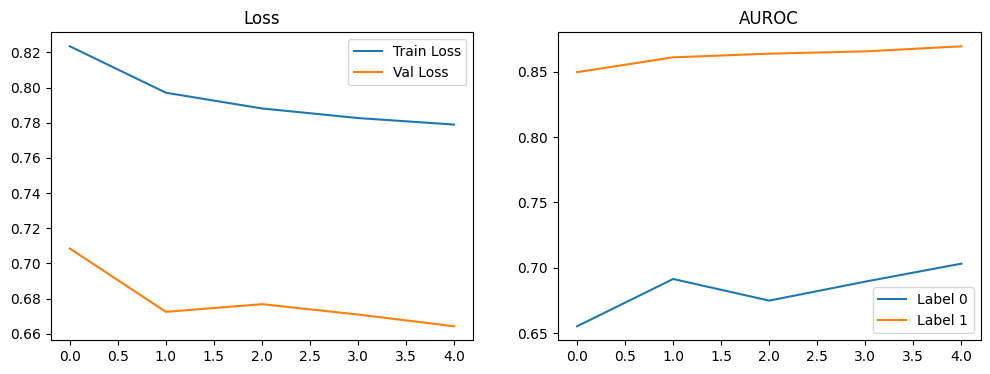

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


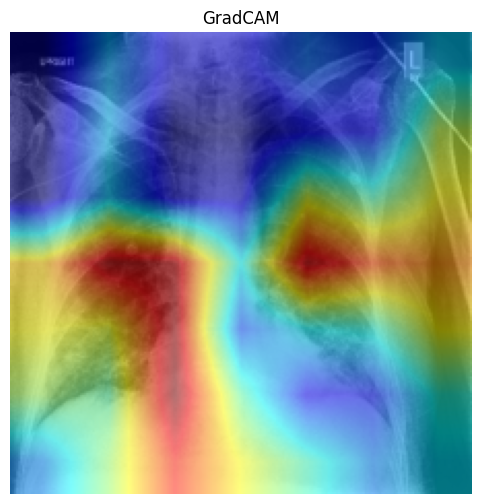

In [39]:
# =========================================================
# Device
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# Load DenseNet121
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import cv2
import os

weights_path = "/kaggle/input/datasets/manelteffahi/weights/densenet121-a639ec97.pth"

model = models.densenet121(weights=None)

state_dict = torch.load(weights_path, map_location=device)
state_dict = {k:v for k,v in state_dict.items() if "classifier" not in k}

model.load_state_dict(state_dict, strict=False)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)

model = model.to(device)

for param in model.features.parameters():
    param.requires_grad = True

# =========================================================
# Loss + Optimizer + Scheduler (Improved)
# =========================================================

# class imbalance handling
pos_weight = torch.tensor([4.0,1.5]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

scaler = torch.cuda.amp.GradScaler()

# =========================================================
# GradCAM (unchanged)
# =========================================================
class GradCAMSimple:
    
    def __init__(self, model, target_layer):
        
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx):
        
        self.model.zero_grad()
        
        output = self.model(input_tensor)
        
        loss = output[:,class_idx].sum()
        
        loss.backward()
        
        grads = self.gradients
        activations = self.activations
        
        weights = torch.mean(grads, dim=(2,3), keepdim=True)
        
        cam = torch.sum(weights * activations, dim=1)
        
        cam = torch.relu(cam)
        
        cam = cam - cam.min()
        cam = cam/(cam.max()+1e-8)
        
        cam = torch.nn.functional.interpolate(
            cam.unsqueeze(1),
            size=input_tensor.shape[2:],
            mode="bilinear"
        )
        
        return cam.squeeze().cpu().numpy()

# =========================================================
# Training
# =========================================================

num_epochs = 5

checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

train_losses = []
val_losses = []
val_aurocs = []
val_f1s = []

# better thresholds
thresholds = [0.25,0.45]

for epoch in range(num_epochs):

    # ================= TRAIN =================
    
    model.train()
    
    running_loss = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for images, labels in train_bar:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            
            outputs = model(images)
            
            # label smoothing
            smooth_labels = labels*0.9 + 0.05
            
            loss = criterion(outputs, smooth_labels)
        
        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        
        scaler.update()
        
        running_loss += loss.item()*images.size(0)
        
        train_bar.set_postfix(loss=loss.item())
    
    train_loss = running_loss/len(train_loader.dataset)
    
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    
    model.eval()
    
    val_loss = 0
    
    all_preds = []
    all_labels = []
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    
    with torch.no_grad():
        
        for images, labels in val_bar:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()*images.size(0)
            
            preds = torch.sigmoid(outputs).cpu().numpy()
            
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    
    val_loss /= len(val_loader.dataset)
    
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    aurocs = []
    f1s = []
    
    for i in range(all_labels.shape[1]):
        
        try:
            auroc = roc_auc_score(all_labels[:,i], all_preds[:,i])
        except:
            auroc = 0
        
        aurocs.append(auroc)
        
        f1 = f1_score(
            all_labels[:,i],
            (all_preds[:,i] > thresholds[i]).astype(int)
        )
        
        f1s.append(f1)
    
    val_aurocs.append(aurocs)
    val_f1s.append(f1s)
    
    print("\nEpoch", epoch+1)
    print("Train Loss:", round(train_loss,4),
          "| Val Loss:", round(val_loss,4))
    print("Val AUROC:", aurocs)
    print("Val F1:", f1s)

    torch.save(
        model.state_dict(),
        os.path.join(checkpoint_dir,f"densenet_epoch{epoch+1}.pth")
    )

# =========================================================
# Plot Training
# =========================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)

val_aurocs_array = np.array(val_aurocs)

for i in range(val_aurocs_array.shape[1]):
    plt.plot(val_aurocs_array[:,i], label=f"Label {i}")

plt.legend()
plt.title("AUROC")

plt.show()

# =========================================================
# GradCAM Example
# =========================================================

images,labels = next(iter(val_loader))

images = images.to(device)

grad_cam = GradCAMSimple(model, model.features.denseblock4)

image_idx = 0
class_idx = 0

heatmap = grad_cam.generate(
    images[image_idx].unsqueeze(0),
    class_idx
)

img_np = images[image_idx].cpu().permute(1,2,0).numpy()

img_np = (img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8)

heatmap_color = cv2.applyColorMap(
    np.uint8(255*heatmap),
    cv2.COLORMAP_JET
)

heatmap_color = heatmap_color[...,::-1]/255.0

overlay = 0.5*img_np + 0.5*heatmap_color

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("GradCAM")
plt.show()

In [46]:
import os
save_path = "/kaggle/working/model.pth"

torch.save(model.state_dict(), save_path)

print("Model saved at:", save_path)
print("Files in working dir:", os.listdir("/kaggle/working"))

Model saved at: /kaggle/working/model.pth
Files in working dir: ['.virtual_documents', 'model.pth', 'checkpoints']


In [45]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch
import numpy as np
from sklearn.metrics import roc_auc_score

# =========================
# LOAD OFFICIAL VALID SET
# =========================
test_df = pd.read_csv("/kaggle/input/datasets/ashery/chexpert/valid.csv")

# keep only frontal
test_df = test_df[test_df['Frontal/Lateral'] == 'Frontal']

# preprocessing (SAME as training)
test_df = test_df.fillna(0)
test_df['Pneumonia'] = test_df['Pneumonia'].replace(-1, 1)
test_df['Pleural Effusion'] = test_df['Pleural Effusion'].replace(-1, 0)
test_df['Path'] = test_df['Path'].str.replace('^CheXpert-v1.0-small/', '', regex=True)

# =========================
# DATASET CLASS (reuse yours)
# =========================
class CheXpertDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(root_dir, row['Path'])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(
            [row['Pneumonia'], row['Pleural Effusion']],
            dtype=torch.float32
        )

        return image, labels


test_dataset = CheXpertDataset(test_df, root_dir, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# =========================
# EVALUATION LOOP
# =========================
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# =========================
# METRICS
# =========================
print("\n OFFICIAL TESTING RESULTS ")

for i, name in enumerate(["Pneumonia", "Pleural Effusion"]):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    print(f"{name} AUROC:", round(auc, 4))


 OFFICIAL TESTING RESULTS 
Pneumonia AUROC: 0.741
Pleural Effusion AUROC: 0.926
